In [1]:
import os
from glob import glob
import pandas as pd
import numpy as np
from numpy import expand_dims
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sn
from skimage.transform import resize
from skimage.color import gray2rgb
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import SVG
from tensorflow import keras
from tensorflow.keras import applications, optimizers
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import to_categorical, model_to_dot, plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau



In [2]:
#Download the "Kermany2018" dataset from Kaggle, which contains OCT (Optical Coherence Tomography)
# images of the retina. It is commonly used for training and evaluating deep
# learning models in retinal image classification (model for detecting conditions
# like CNV, DME, and Drusen).

!kaggle datasets download -d paultimothymooney/kermany2018


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/kermany2018
License(s): CC-BY-NC-SA-4.0
100% 10.8G/10.8G [01:53<00:00, 103MB/s]



In [3]:
# Extract the contents of the kermany2018.zip file.
# This will create folders (e.g., train, test, validation) containing the dataset images,
# which are needed for building and evaluating deep learning models.

!unzip kermany2018.zip



Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8050636-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8056259-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8056259-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8056259-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8056259-4.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8056259-5.jpeg

In [4]:
# List all files and folders in the /content directory
# to verify that the dataset and extracted files are present.

!ls /content


 kermany2018.zip   oct2017  'OCT2017 '	 sample_data


In [5]:
# List all files and folders in the inside folders in the /content directory

!ls -l /content/oct2017
!ls -l /content/OCT2017
!ls -l "/content/OCT2017 "

total 8
drwxr-xr-x 3 root root 4096 Mar 31 13:37  __MACOSX
drwxr-xr-x 5 root root 4096 Mar 31 13:37 'OCT2017 '
ls: cannot access '/content/OCT2017': No such file or directory
total 12
drwxr-xr-x 6 root root 4096 Mar 31 13:33 test
drwxr-xr-x 6 root root 4096 Mar 31 13:34 train
drwxr-xr-x 6 root root 4096 Mar 31 13:35 val


In [6]:
# Clean up old dataset folders (if they exist) to prevent errors.
# The extracted folder may have an incorrect name (e.g., with a trailing space),
# so we rename it to 'oct2017' to maintain a consistent directory structure.

!rm -rf /content/oct2017
!rm -rf /content/OCT2017
!mv "/content/OCT2017 " /content/oct2017



In [7]:
# Check inside the 'oct2017' folder to ensure it contains the required subfolders.
# Assign paths for train, validation, and test datasets so they can be easily referenced
# when creating data generators or loading images for model training and evaluation.

!ls "/content/oct2017"
train_data_dir = "/content/oct2017/train/"
val_data_dir   = "/content/oct2017/val/"
test_data_dir  = "/content/oct2017/test/"



test  train  val


In [8]:
# Define the main dataset directory and its subdirectories.
# These paths point to the training, validation, and test folders,
# which will be used for loading and organizing data during model training and evaluation.

data_dir = "/content/oct2017/"
train_data_dir = "/content/oct2017/train/"
val_data_dir = "/content/oct2017/val/"
test_data_dir = "/content/oct2017/test/"


# Image dimensions (width and height in pixels)
img_width, img_height = 150, 150

# Number of color channels in the image
channels = 3

# Number of images processed at once during training
batch_size = 32

Explanation o the concepts used in earlier cell (code snippet)

**Image dimensions (`img_width`, `img_height` = 150, 150):**
These define the size of the input images given to the model. Every image is resized to 150 × 150 pixels before training so that all inputs have a consistent shape. Smaller image sizes make training faster but may lose important details, while larger sizes preserve more detail but require more memory and computation.

**Number of channels (`channels = 3`):**
This represents how color information is stored in each image. A value of 3 means the image is in RGB format (Red, Green, Blue), where each pixel contains three values corresponding to these colors. If the image were grayscale, it would have only 1 channel.

**Batch size (`batch_size = 32`):**
This determines how many images are processed by the model at one time during training. Instead of feeding all images at once, the dataset is divided into smaller groups called batches. A batch size of 32 means the model learns from 32 images at a time, which helps balance memory usage and training speed while improving learning stability.


In [9]:
# Iterate over each class folder inside the training directory.
# 'category' represents the class name (e.g., CNV, DME, NORMAL, DRUSEN).
# Count and print the number of images in each class to check dataset balance.

for category in os.listdir(train_data_dir):
    path = os.path.join(train_data_dir, category)
    print(category, ":", len(os.listdir(path)))


DME : 11348
NORMAL : 26315
CNV : 37205
DRUSEN : 8616


In [10]:
# Import glob to search for files using patterns (e.g., *.jpg, *.jpeg)

from glob import glob

# Count the number of images in each category by searching for .jpeg and .jpg files
# in their respective folders inside the training directory.

cnv_images = len(glob(train_data_dir + 'CNV/*.jpeg')) + len(glob(train_data_dir + 'CNV/*.jpg'))
dme_images = len(glob(train_data_dir + 'DME/*.jpeg')) + len(glob(train_data_dir + 'DME/*.jpg'))
drusen_images = len(glob(train_data_dir + 'DRUSEN/*.jpeg')) + len(glob(train_data_dir + 'DRUSEN/*.jpg'))
normal_images = len(glob(train_data_dir + 'NORMAL/*.jpeg')) + len(glob(train_data_dir + 'NORMAL/*.jpg'))

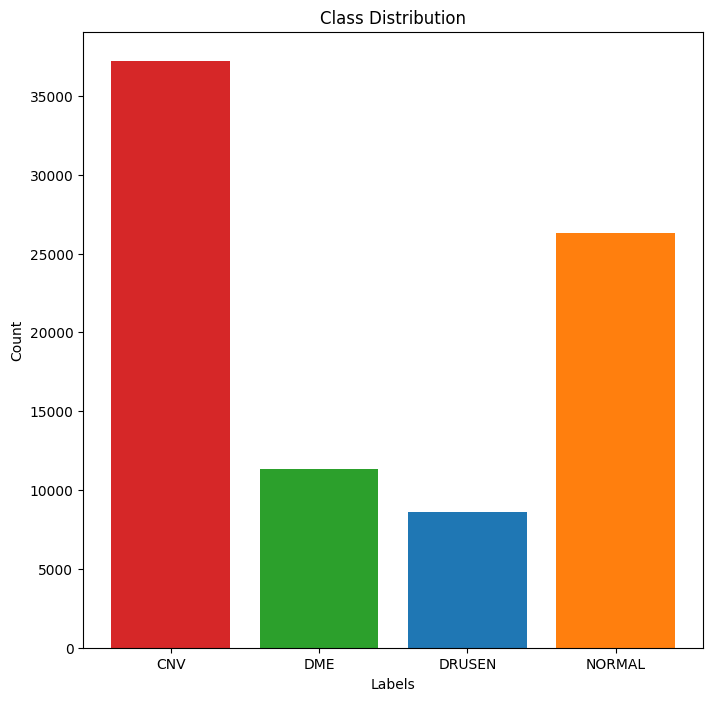

In [11]:
# This section visualizes the distribution of images across different classes.
# A dictionary is created to map each category (CNV, DME, DRUSEN, NORMAL) to its image count.
# The labels and counts are extracted and used to plot a bar chart using matplotlib.
# The chart helps in understanding class balance or imbalance in the dataset.
# The figure size is adjusted for better visibility, and different colors are used for each class.
# The plot is labeled (axes and title), saved as an image file, and then displayed.

import matplotlib.pyplot as plt

data = {
    'CNV': cnv_images,
    'DME': dme_images,
    'DRUSEN': drusen_images,
    'NORMAL': normal_images
}

labels = list(data.keys())
count = list(data.values())

plt.rcParams['figure.figsize'] = (8.0, 8.0)

plt.bar(labels, count, color=['tab:red', 'tab:green', 'tab:blue', 'tab:orange'])

plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.savefig('labels_vs_counts.png', bbox_inches='tight', dpi=400)
plt.show()

Sample Images from the Dataset

Normal


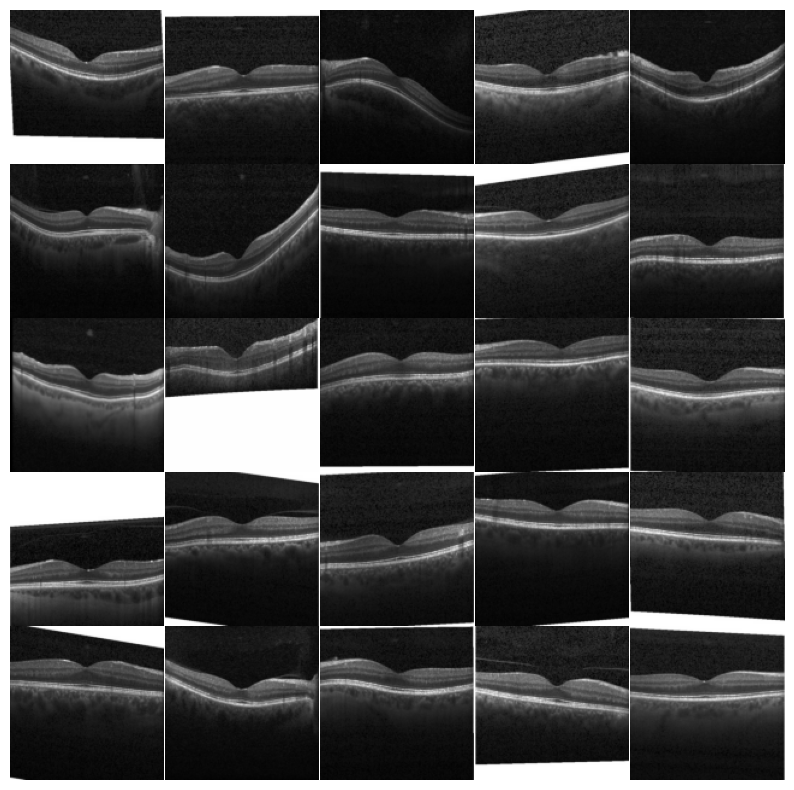

In [12]:
# This section displays a sample of 25 images from the "NORMAL" class.
# It first collects all image file paths from the NORMAL training folder.
# Then, it loops through the first 25 images, reads each image, resizes it to 128x128,
# and displays them in a 5x5 grid using matplotlib.
# The images are converted to RGB format (if needed) and axes are turned off for cleaner visualization.
# Finally, the grid of images is saved as 'normal_eye.png' for reference.

print("Normal")
multipleImages = glob(data_dir + 'train/NORMAL/**')
i = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for im in multipleImages[:25]:
    image = mpimg.imread(im)
    image_resized = resize(image, (128, 128))
    plt.subplot(5, 5, i+1) #.set_title(l)
    plt.imshow(gray2rgb(image_resized)); plt.axis('off')
    i += 1
plt.savefig('normal_eye.png', transparent= False, bbox_inches= 'tight', dpi= 400)

Choroidal Neo-Vascularization (CNV)


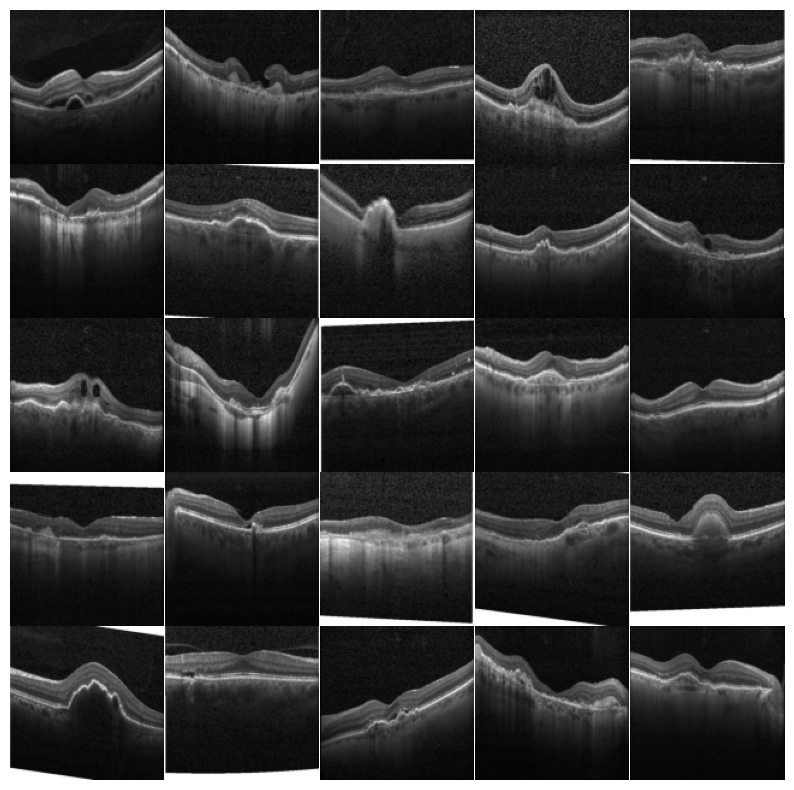

In [13]:
# This section visualizes sample images from the "CNV" (Choroidal Neo-Vascularization) class.
# It collects all image paths from the CNV training folder and selects the first 25 images.
# Each image is read, resized to 128x128 for uniformity, and displayed in a 5x5 grid.
# The images are converted to RGB format (if needed), and axes are hidden for better visualization.
# Finally, the grid is saved as 'cnv_eye.png' to observe patterns specific to CNV images.

print("Choroidal Neo-Vascularization (CNV)")
multipleImages = glob(data_dir + 'train/CNV/**')
i = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for im in multipleImages[:25]:
    image = mpimg.imread(im)
    image_resized = resize(image, (128, 128))
    plt.subplot(5, 5, i+1) #.set_title(l)
    plt.imshow(gray2rgb(image_resized)); plt.axis('off')
    i += 1
plt.savefig('cnv_eye.png', transparent= False, bbox_inches= 'tight', dpi= 400)

Diabetic Macular Edema (DME)


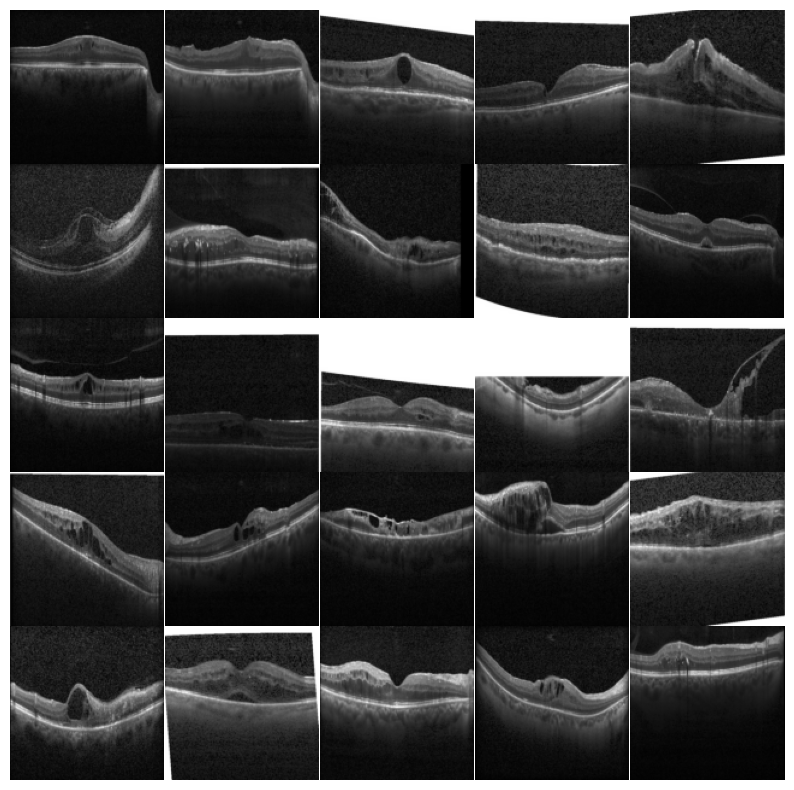

In [14]:
# This section displays sample images from the "DME" (Diabetic Macular Edema) class.
# It gathers image file paths from the DME training folder and selects the first 25 images.
# Each image is loaded, resized to 128x128 for consistency, and arranged in a 5x5 grid.
# Images are converted to RGB format (if needed), and axes are removed for a cleaner view.
# The final grid is saved as 'dme_eye.png' to help visualize features of DME images.

print("Diabetic Macular Edema (DME)")
multipleImages = glob(data_dir + 'train/DME/**')
i = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for im in multipleImages[:25]:
    image = mpimg.imread(im)
    image_resized = resize(image, (128, 128))
    plt.subplot(5, 5, i+1) #.set_title(l)
    plt.imshow(gray2rgb(image_resized)); plt.axis('off')
    i += 1
plt.savefig('dme_eye.png', transparent= False, bbox_inches= 'tight', dpi= 400)

Drusen (AMD)


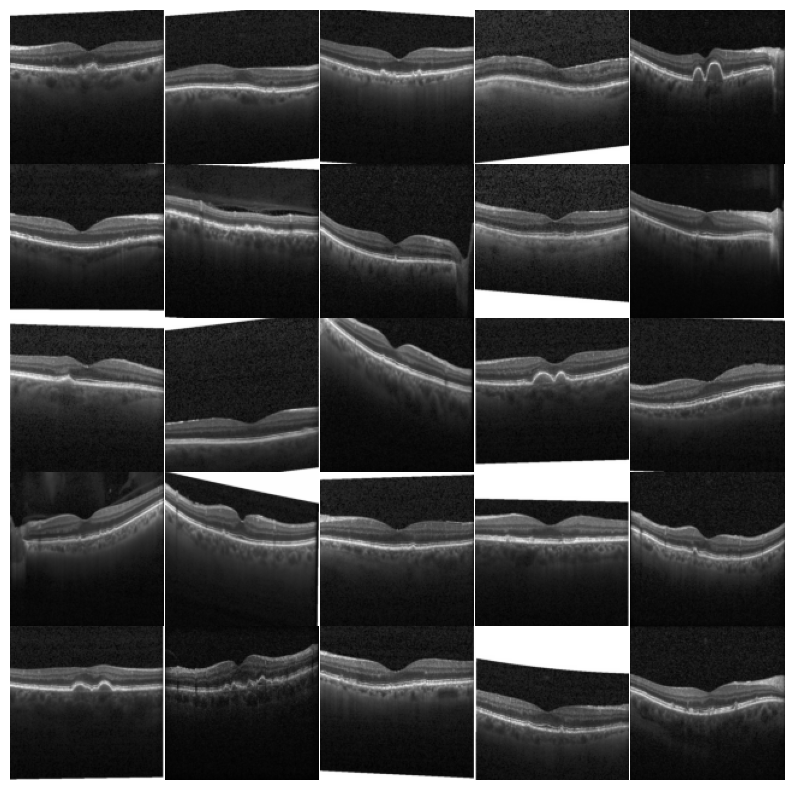

In [15]:
# This section visualizes sample images from the "DRUSEN" (a form of Age-related Macular Degeneration) class.
# It collects image paths from the DRUSEN training folder and selects the first 25 images.
# Each image is read, resized to 128x128 for uniform input size, and displayed in a 5x5 grid.
# Images are converted to RGB format (if needed), and axes are hidden for better clarity.
# The resulting grid is saved as 'drusen_eye.png' to help observe visual patterns in DRUSEN images.

print("Drusen (AMD)")
multipleImages = glob(data_dir + 'train/DRUSEN/**')
i = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for im in multipleImages[:25]:
    image = mpimg.imread(im)
    image_resized = resize(image, (128, 128))
    plt.subplot(5, 5, i+1) #.set_title(l)
    plt.imshow(gray2rgb(image_resized)); plt.axis('off')
    i += 1
plt.savefig('drusen_eye.png', transparent= False, bbox_inches= 'tight', dpi= 400)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#  Training data generator (with augmentation)
train_datagen = ImageDataGenerator(

    # Normalize pixel values (0–255 → 0–1)
    rescale=1.0 / 255,

    # Random zoom (73% to 90% of original size)
    zoom_range=(0.73, 0.9),

    # Random horizontal flip (50% chance)
    horizontal_flip=True,

    # Random rotation between -10° and +10°
    rotation_range=10,

    # Random horizontal shift (up to 10%)
    width_shift_range=0.10,

    # Random vertical shift (up to 10%)
    height_shift_range=0.10,

    # Random brightness change
    brightness_range=(0.55, 0.9),

    # Fill empty areas after transformations
    fill_mode='constant'
)


# Validation & Test generator (NO augmentation)
valid_test_datagen = ImageDataGenerator(

    # Only normalize (no changes to images)
    rescale=1.0 / 255
)

Notes for the code used earlier:


In this step, we use ImageDataGenerator to prepare the images before training the model. This helps the model learn better and improves its performance.
We create two generators:
one for training data and one for validation/test data.


**Training Data Generator:**

The training data generator applies both normalization and random changes to the images. These changes are called data augmentation.

**Rescale:**
Image pixel values are originally between 0 and 255. We divide them by 255 to convert them into the range 0 to 1. This makes training faster and more stable.

**Zoom:**
The image is randomly zoomed in. This helps the model learn features at different sizes.

**Horizontal flip:**
The image may be flipped left to right. This increases the variety of training data and helps the model generalize better.

**Rotation:**
The image is rotated slightly (up to 10 degrees). This helps the model handle images that are not perfectly straight.

**Width shift:**
The image is moved slightly left or right (up to 10%). This teaches the model that objects may not always be centered.

**Height shift:**
The image is moved slightly up or down (up to 10%). This improves the model’s ability to recognize objects in different positions.

**Brightness:**
The brightness of the image is changed randomly. This helps the model work better under different lighting conditions.

**Fill mode:**
When images are shifted or rotated, empty spaces may appear. These spaces are filled with a constant value so the image remains complete.

All these transformations make the training data more diverse and help reduce overfitting.

In [17]:
# Create data generators that load images from directories in batches.
# The training generator applies augmentation and prepares shuffled batches for learning.
# The validation generator loads normalized images (no augmentation) to monitor model performance during training.
# The test generator loads normalized images without shuffling to ensure consistent and correct evaluation.
# All images are resized to a fixed size, loaded in RGB format, and labels are encoded for multi-class classification.

# TRAINING GENERATOR (with augmentation)
train_generator = train_datagen.flow_from_directory(
    directory=train_data_dir,          # path to training data

    target_size=(img_width, img_height),  # resize all images to 150x150

    color_mode='rgb',                 # load images as color (3 channels)

    batch_size=batch_size,            # number of images per batch (e.g., 32)

    class_mode='categorical',         # multi-class labels (one-hot encoded)

    shuffle=True,                     # shuffle images every epoch

    seed=1337                         # for reproducibility
)


# VALIDATION GENERATOR (NO augmentation)
valid_generator = valid_test_datagen.flow_from_directory(
    directory=val_data_dir,           # path to validation data

    target_size=(img_width, img_height),

    color_mode='rgb',

    batch_size=batch_size,

    class_mode='categorical',

    shuffle=True,                     # OK for validation

    seed=1337
)


# TEST GENERATOR (NO augmentation, NO shuffle)
test_generator = valid_test_datagen.flow_from_directory(
    directory=test_data_dir,          # path to test data

    target_size=(img_width, img_height),

    color_mode='rgb',

    batch_size=batch_size,

    class_mode='categorical',

    shuffle=False                    # IMPORTANT → keep order fixed
)

Found 83484 images belonging to 4 classes.
Found 32 images belonging to 4 classes.
Found 968 images belonging to 4 classes.


In [18]:
# Determine the number of classes from the training generator.
# Extract class labels (as integers) for training and validation datasets,
# and convert them into one-hot encoded format for multi-class classification.
# Also, count the total number of images in training, validation, and test datasets.

from tensorflow.keras.utils import to_categorical

# Number of classes (4: CNV, DME, DRUSEN, NORMAL)
num_classes = len(train_generator.class_indices)


# Get training labels (as integers)
train_labels = train_generator.classes
# Example: [0, 0, 1, 2, 3, 1, ...]

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels, num_classes=num_classes)
# Example: [1,0,0,0], [0,1,0,0], ...


# Validation labels (same process)
valid_labels = valid_generator.classes
valid_labels = to_categorical(valid_labels, num_classes=num_classes)


# Count number of images in each dataset
nb_train_samples = len(train_generator.filenames)
nb_valid_samples = len(valid_generator.filenames)
nb_test_samples  = len(test_generator.filenames)

**Class indices and labels**

Each class such as CNV, DME, DRUSEN, and NORMAL is automatically assigned a number by the data generator.

For example, CNV may be assigned 0, DME as 1, DRUSEN as 2, and NORMAL as 3.

So instead of class names, the model initially sees labels like a list of numbers such as 0, 0, 1, 2, 3, 1 and so on.

**One hot encoding**

**One hot encoding** converts these numbers into a different format that the model can understand better.
Instead of representing a class with a single number, each class is represented as a list where one position is marked as 1 and the rest are 0.
For example, in a problem with four classes
Class 0 becomes a list where the first position is 1 and others are 0
Class 1 becomes a list where the second position is 1 and others are 0
Class 2 becomes a list where the third position is 1 and others are 0
Class 3 becomes a list where the fourth position is 1 and others are 0
This way, each class is clearly separated and treated independently.
Why we use one hot encoding
Neural networks work better with this format
It prevents the model from thinking one class is greater or smaller than another
It is required for multi class classification problems

**Number of samples**

The training generator keeps a list of all image file names in the training dataset
Using the length of this list gives the total number of training images
The same method is used for validation and test datasets
This helps us know how many images are available in each dataset
Why this is useful
It helps us understand the size of the dataset
It is needed when setting training parameters such as steps per epoch
Simple summary
Labels are converted from numbers into a format the model understands better
This helps the model correctly learn multiple classes
The total number of images is counted to manage training and evaluation properly

Image Data Augmentation (shows here how different augmentation of the original image looks like )


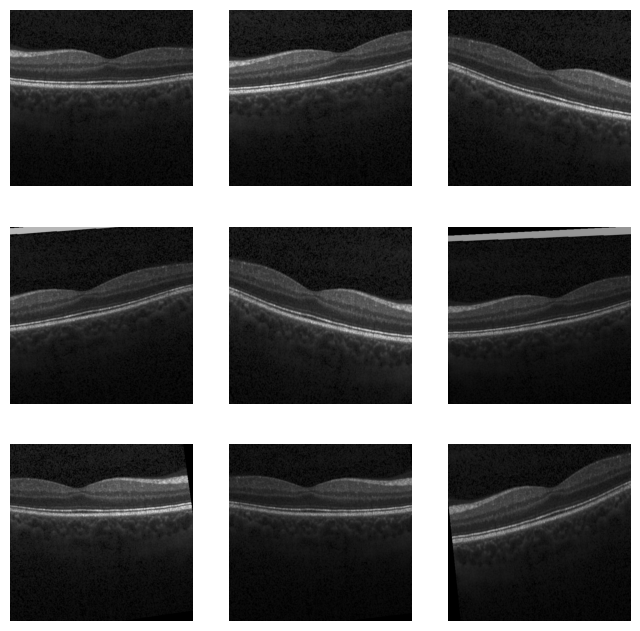

In [19]:
# This section demonstrates data augmentation on a single sample image.
# The image is loaded, converted into an array, and reshaped to match the model's input format.
# Using the training data generator, multiple augmented versions of the same image are created.
# These augmented images are then displayed in a grid to visualize how transformations
# like rotation, zoom, shifting, and brightness changes modify the original image.
# This helps in understanding how data augmentation increases dataset diversity.

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from numpy import expand_dims
import matplotlib.pyplot as plt

# Step 1: Load one image
img_path = "/content/oct2017/train/NORMAL/NORMAL-1001772-4.jpeg"
img = load_img(img_path)

# Step 2: Convert image → numpy array
data = img_to_array(img)

# Step 3: Add batch dimension (required shape: (1, height, width, channels))
samples = expand_dims(data, axis=0)

# Step 4: Create an iterator using your augmentation rules
it = train_datagen.flow(samples, batch_size=1)

# Step 5: Plot augmented images
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i+1)

    batch = next(it)          # get one augmented version
    image = batch[0]          # extract image from batch

    plt.imshow(image)
    plt.axis('off')

# Save and display
plt.savefig('augmented_image.png', bbox_inches='tight', dpi=400)
plt.show()

Loading the pretrained VGG16 model

In [20]:
# Load the VGG16 model pretrained on ImageNet, excluding its top classification layers.
# This allows us to use it as a feature extractor for our dataset.
# The input shape is set according to our image size and channels,
# and the model architecture is displayed to understand its structure.

from tensorflow.keras.applications import VGG16

# Load pretrained VGG16 model
vgg16 = VGG16(
    include_top=False,                     # remove final classification layers
    input_shape=(img_width, img_height, channels),
    weights='imagenet'                     # load pretrained weights
)

# Show model architecture
vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Concept Explanation:**

**Pretrained Networks (Transfer Learning):**
A pretrained network is a model that has already been trained on a large dataset, such as ImageNet, which contains millions of images from many different categories. Instead of training a model from scratch, we reuse this existing knowledge.
Deep learning models like VGG16 learn general features in the early layers, such as edges, textures, and shapes. These features are useful for many different image tasks, not just the original dataset they were trained on.
By using a pretrained model, we take advantage of this learned knowledge and apply it to a new problem, such as medical image classification. This approach is called transfer learning.
In this code, we remove the top classification layers of VGG16 because they are specific to ImageNet classes. Instead, we keep the convolutional base, which acts as a feature extractor. We can then add our own custom layers on top to classify our specific categories like CNV, DME, DRUSEN, and NORMAL.
Benefits of using pretrained networks:

Reduces training time

Requires less data

Improves performance, especially when the dataset is small

Helps the model learn better features

In simple terms, instead of teaching the model everything from the beginning, we start with a model that already understands images and adapt it to our specific task.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# Step 1: Add all VGG16 layers
for layer in vgg16.layers:
    model.add(layer)

#  Step 2: Freeze all layers (no training for VGG16)
for layer in model.layers:
    layer.trainable = False

# Step 3: Flatten feature maps into 1D vector
model.add(Flatten(input_shape=(4, 4, 512)))

# Step 4: Add dropout (reduce overfitting)
model.add(Dropout(0.2))

# Step 5: Final classification layer (4 classes)
model.add(Dense(4, activation='softmax'))

# Show model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │        32,772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,460 (56.26 MB)

 Trainable params: 32,772 (128.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
# Compile the model by defining how it should learn.
# The Adam optimizer is used with a specified learning rate to update model weights.
# 'categorical_crossentropy' is used as the loss function for multi-class classification.
# 'accuracy' is used as a metric to evaluate how well the model predicts the correct class.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# Compile the model by defining the optimizer, loss function, and evaluation metric.
# The Adam optimizer is used with a fixed learning rate, and categorical crossentropy
# is used for multi-class classification. Accuracy is used to measure performance.

# Define callbacks to improve and control the training process:
# ModelCheckpoint saves the best model based on validation loss.
# EarlyStopping stops training if the model stops improving, preventing overfitting.
# CSVLogger records training progress (loss and accuracy) into a file for later analysis.
# ReduceLROnPlateau (commented out) can be used to reduce the learning rate automatically
# when the model stops improving, helping achieve better convergence.

# All selected callbacks are combined into a list and passed during model training.

from tensorflow import keras

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau

# Save the best model during training
checkpoint = ModelCheckpoint(
    filepath='baseline_model.h5',     # file to save model
    monitor='val_loss',               # watch validation loss
    verbose=1,
    save_best_only=True,              # save only if performance improves
    mode='min',                       # lower loss = better
    save_weights_only=False,
    save_freq='epoch'                 # save every epoch
)


# Stop training early if no improvement
earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,                  # minimum improvement required
    patience=3,                      # wait 3 epochs before stopping
    verbose=1,
    mode='min'
)


# Log training results to a CSV file
csvlogger = CSVLogger(
    filename="baseline_training_csv.log",
    separator=",",
    append=False
)


# Reduce learning rate when model stops improving
#reduceLR = ReduceLROnPlateau(
    #monitor='val_loss',
    #factor=0.1,                      # reduce LR by 10x
    #patience=3,                      # wait 3 epochs
    #verbose=1,
    #mode='min'
#)


# Combine all callbacks
callbacks = [checkpoint, earlystop, csvlogger]

In [ ]:
all_history = {}

# Train the model using the training data generator.
# The model learns in batches, with a fixed number of steps per epoch
# instead of using the entire dataset.
# Validation data is used to monitor performance after each epoch.
# Training runs for a fixed number of epochs, and callbacks are applied
# to save the best model, stop early if needed, and log results.
# 'verbose=1' displays training progress during execution.


history = model.fit(
    train_generator,
    steps_per_epoch=200,
    validation_data=valid_generator,
    validation_steps=50,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)



all_history["lr_0.0001"] = history.history

Epoch 1/5
187/200 ━━━━━━━━━━━━━━━━━━━━ 2:10 10s/step - accuracy: 0.4952 - loss: 1.2352

In [ ]:
# Visualize the model's training performance over epochs with loss and val_loss.
# The first plot shows how training and validation loss change during training.
# The second plot shows how training and validation accuracy improve over time.
# These graphs help in understanding model learning behavior and detecting issues
# like overfitting or underfitting.


import matplotlib.pyplot as plt


In [ ]:
# Evaluate the trained model on the validation dataset.
# Generate predictions and compare them with true labels to compute
# performance metrics such as precision, recall, and F1-score for each class.
# These metrics are then extracted and visualized using a bar chart,
# allowing easy comparison of how well the model performs across different categories.
all_results = []


from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
valid_generator.reset()
# Predict on validation set

y_prob = model.predict(valid_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# True labels
y_true = valid_generator.classes

# Class names in the correct order
class_names = list(valid_generator.class_indices.keys())

# Print report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Convert report to dict
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

precision = []
recall = []
f1 = []

for cls in class_names:
    precision.append(report_dict[cls]['precision'])
    recall.append(report_dict[cls]['recall'])
    f1.append(report_dict[cls]['f1-score'])

# Plot
x = np.arange(len(class_names))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1-score')

plt.xticks(x, class_names)
plt.ylabel("Score")
plt.title("Class-wise Performance Metrics")
plt.ylim(0, 1)
plt.legend()
plt.show()



# Append results (IMPORTANT: give a label instead of lr)
for cls in class_names:
    all_results.append({
        'learning_rate': 'baseline',   # 👈 label it clearly
        'class': cls,
        'precision': report[cls]['precision'],
        'recall': report[cls]['recall'],
        'f1_score': report[cls]['f1-score']
    })

**Game 1: Vary the learning rate from (0.00001 to 0.001) at the same epochs and steps_per_epoch=200**. Report how the accuracy metrics for different classes change.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Define a Convolutional Neural Network (CNN) model for image classification.
# The model consists of multiple convolution and pooling layers to extract features,
# followed by fully connected layers for classification.
# Convolution layers learn patterns such as edges and textures,
# while pooling layers reduce spatial size and computation.
# The Flatten layer converts feature maps into a 1D vector,
# which is then passed through dense layers.
# Dropout can be used to reduce overfitting by randomly disabling neurons during training.
# The final Dense layer uses softmax activation to classify images into 4 categories.



In [ ]:
learning_rates = [0.00001, 0.001]

# Store metrics for each learning rate and each class

    # Build fresh model each time

    # Callbacks

    # Train model

    # Predict on validation set

    # Classification report as dictionary

    # Store precision, recall, and f1-score for each class

# Print results


**Game 2: The goal of this experiment is to train a model which can clearly distinguish between healthy retinal images (NORMAL) and retinal images with DRUSEN (associated with Age-related Macular Degeneration – AMD).**
Instead of solving the full 4-class problem (CNV, DME, DRUSEN, NORMAL), this experiment simplifies the task into a binary classification problem.
The goal is to see how muhc the accuracy improves if it gets trained as a binary classification problem.


In [ ]:
import os
import shutil

src_base = "/content/oct2017"
dst_base = "/content/oct_binary_vgg"

classes_to_keep = ["NORMAL", "DRUSEN"]
splits = ["train", "val", "test"]

# =====================================================
# Create binary dataset
# =====================================================


data_dir = dst_base
train_data_dir = os.path.join(data_dir, "train")
val_data_dir = os.path.join(data_dir, "val")
test_data_dir = os.path.join(data_dir, "test")

print("\nPaths:")
print("data_dir =", data_dir)
print("train_data_dir =", train_data_dir)
print("val_data_dir =", val_data_dir)
print("test_data_dir =", test_data_dir)

print("\nCounts:")
for split in splits:
    print(f"\n{split.upper()}")
    for cls in classes_to_keep:
        folder = os.path.join(data_dir, split, cls)
        count = len(os.listdir(folder)) if os.path.exists(folder) else 0
        print(f"{cls}: {count}")

print("\nTree:")
for split in splits:
    print(f"{split}/")
    for cls in classes_to_keep:
        folder = os.path.join(data_dir, split, cls)
        count = len(os.listdir(folder)) if os.path.exists(folder) else 0
        print(f"    {cls}/ ({count} images)")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    zoom_range=(0.73, 0.9),
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=(0.55, 0.9),
    fill_mode='constant'
)

valid_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_generator =

valid_generator =

test_generator =

In [ ]:
# =====================================================
# NUMBER OF CLASSES
# =====================================================
num_classes =
print("Number of classes:", num_classes)

# =====================================================
# LABELS (NO ONE-HOT NEEDED FOR BINARY)
# =====================================================
train_labels =
valid_labels =
test_labels  =

# Example output: [0, 1, 1, 0, ...]

print("\nSample labels:")
print("Train:", train_labels[:10])
print("Validation:", valid_labels[:10])
print("Test:", test_labels[:10])

# =====================================================
# COUNT IMAGES
# =====================================================
nb_train_samples =
nb_valid_samples =
nb_test_samples  =

print("\nDataset sizes:")
print("Train samples:", nb_train_samples)
print("Validation samples:", nb_valid_samples)
print("Test samples:", nb_test_samples)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# =====================================================
# LOAD VGG16 (FEATURE EXTRACTOR)
# =====================================================


# =====================================================
# BUILD MODEL
# =====================================================
model=
# Add VGG16 layers


# Freeze all VGG16 layers

# =====================================================
# CUSTOM CLASSIFIER (UPDATED FOR 2 CLASSES)
# =====================================================


# CHANGE HERE: binary output


# =====================================================
# SUMMARY
# =====================================================
model.summary()

In [ ]:
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau

# =====================================================
# COMPILE MODEL FOR BINARY CLASSIFICATION
# =====================================================


# =====================================================
# CALLBACKS
# =====================================================

# Save the best model during training

# Stop training early if validation loss does not improve

# Log training results to CSV

# Optional: reduce learning rate when validation loss plateaus


# Combine callbacks
callbacks = [checkpoint, earlystop, csvlogger]

In [ ]:
# =====================================================
# TRAIN MODEL
# =====================================================


# Loss and Accuracy plots


# Loss plot


# Accuracy plot


In [ ]:
all_results = []

from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Reset generator before prediction
valid_generator.reset()

# Predict probabilities
y_prob =

# Convert probabilities to binary class labels
# Since output layer is Dense(1, activation='sigmoid')
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# True labels
y_true =

# Class names in the correct order
# Example: {'DRUSEN': 0, 'NORMAL': 1}
class_indices = valid_generator.class_indices
class_names = list(class_indices.keys())

# Print classification report
report =
print(report)

# Convert report to dictionary

# Plot class-wise metrics

# Store results


 **Game 3: Binary Classification (Custom CNN)
Objective
The goal remains the same:
Distinguish between NORMAL and DRUSEN images
However, instead of using a pretrained model like VGG16, use a custom CNN trained from scratch and compare the accuracy metrics of the one with pretraiend model at the same epochs, step size, bath size and learning rate to understand the effect of pretrained models and transfer learning.**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow import keras

# =====================================================
# NORMAL CNN MODEL FOR BINARY CLASSIFICATION
# =====================================================
model = Sequential()

# Block 1


# Block 2


# Block 3


# Block 4


# Classifier


# Show model summary
model.summary()

In [ ]:
# =====================================================
# COMPILE MODEL FOR BINARY CLASSIFICATION
# =====================================================


# =====================================================
# CALLBACKS
# =====================================================

# Save the best model during training

# Stop training early if validation loss does not improve

# Log training results to CSV

# Optional: reduce learning rate when validation loss plateaus


# Combine callbacks

# =====================================================
# TRAIN MODEL
# =====================================================



# Extract history safely

# ======================
# LOSS PLOT
# ======================


# ======================
# ACCURACY PLOT
# ======================



In [ ]:
all_results = []

from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PREDICTIONS
# =====================================================
valid_generator.reset()

# Probabilities (sigmoid output)
y_prob =

# Convert probabilities → binary labels
y_pred =

# True labels
y_true =

# Class names (e.g., ['DRUSEN', 'NORMAL'])
class_names = list(valid_generator.class_indices.keys())

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

# Convert to dictionary


# =====================================================
# EXTRACT METRICS
# =====================================================
precision = []
recall = []
f1 = []

for cls in class_names:
    precision.append(report_dict[cls]['precision'])
    recall.append(report_dict[cls]['recall'])
    f1.append(report_dict[cls]['f1-score'])

# =====================================================
# PLOT METRICS
# =====================================================


# =====================================================
# STORE RESULTS
# =====================================================

print(all_results)

**Game 4: Effect of Image Resolution on Binary Classification
Objective**
The goal of this experiment is to study how changing image resolution (input size) from 150x150 to 64x64 affects the model’s ability to distinguish between NORMAL and DRUSEN. Keep in mind you need to change training, testing and validation data.

In [ ]:
img_width, img_height = 64, 64
#Change Image sizes



In [ ]:
# =====================================================
# NUMBER OF CLASSES
# =====================================================


# =====================================================
# LABELS (NO ONE-HOT NEEDED FOR BINARY)
# =====================================================
train_labels =
valid_labels =
test_labels  =

# Example output: [0, 1, 1, 0, ...]

print("\nSample labels:")
print("Train:", train_labels[:10])
print("Validation:", valid_labels[:10])
print("Test:", test_labels[:10])

# =====================================================
# COUNT IMAGES
# =====================================================
nb_train_samples = len(train_generator.filenames)
nb_valid_samples = len(valid_generator.filenames)
nb_test_samples  = len(test_generator.filenames)

print("\nDataset sizes:")
print("Train samples:", nb_train_samples)
print("Validation samples:", nb_valid_samples)
print("Test samples:", nb_test_samples)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# =====================================================
# LOAD VGG16 (FEATURE EXTRACTOR)
# =====================================================

# =====================================================
# BUILD MODEL
# =====================================================

# Add VGG16 layers

# Freeze all VGG16 layers

# =====================================================
# CUSTOM CLASSIFIER (UPDATED FOR 2 CLASSES)
# =====================================================

# =====================================================
# SUMMARY
# =====================================================
model.summary()

In [ ]:
# =====================================================
# COMPILE MODEL FOR BINARY CLASSIFICATION
# =====================================================

# =====================================================
# CALLBACKS
# =====================================================

# Save the best model during training

# Stop training early if validation loss does not improve

# Log training results to CSV

# Optional: reduce learning rate when validation loss plateaus

# Combine callbacks

# =====================================================
# TRAIN MODEL
# =====================================================

# Loss and Accuracy plots


# Loss plot

# Accuracy plot


In [ ]:
all_results = []

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PREDICTIONS ON VALIDATION SET
# =====================================================
valid_generator.reset()

# Sigmoid probabilities
y_prob =

# Convert probabilities to binary labels
y_pred =

# True labels
y_true =

# Class names in class-index order
# Example: {'DRUSEN': 0, 'NORMAL': 1}
class_names = list(valid_generator.class_indices.keys())

# =====================================================
# OVERALL ACCURACY
# =====================================================

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

# =====================================================
# EXTRACT CLASS-WISE METRICS
# =====================================================

# =====================================================
# PLOT PRECISION / RECALL / F1
# =====================================================

# =====================================================
# OPTIONAL: SUPPORT BAR PLOT
# =====================================================

# =====================================================
# CONFUSION MATRIX
# =====================================================

# =====================================================
# STORE RESULTS
# =====================================================


**Game 5: Vary the steps per epoch to 400 at the same epochs. Report how the accuracy metrics for different classes improve.**

Upper limit of steps per epoch= total number of images / batch size

This equals to the number of independent batches one can give for each step at a fixed batch size.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# =====================================================
# LOAD VGG16 (FEATURE EXTRACTOR)
# =====================================================

# =====================================================
# BUILD MODEL
# =====================================================

# Add VGG16 layers

# Freeze all VGG16 layers

# =====================================================
# CUSTOM CLASSIFIER (UPDATED FOR 2 CLASSES)
# =====================================================

# =====================================================
# SUMMARY
# =====================================================
model.summary()

In [ ]:
# =====================================================
# COMPILE MODEL FOR BINARY CLASSIFICATION
# =====================================================

# =====================================================
# CALLBACKS
# =====================================================

# Save the best model during training

# Stop training early if validation loss does not improve

# Log training results to CSV

# Optional: reduce learning rate when validation loss plateaus

# Combine callbacks

# =====================================================
# TRAIN MODEL
# =====================================================

# Loss and Accuracy plots


# Loss plot

# Accuracy plot


In [ ]:
all_results = []

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PREDICTIONS ON VALIDATION SET
# =====================================================
valid_generator.reset()

# Sigmoid probabilities
y_prob =

# Convert probabilities to binary labels
y_pred =

# True labels
y_true =

# Class names in class-index order
# Example: {'DRUSEN': 0, 'NORMAL': 1}
class_names = list(valid_generator.class_indices.keys())

# =====================================================
# OVERALL ACCURACY
# =====================================================

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

# =====================================================
# EXTRACT CLASS-WISE METRICS
# =====================================================

# =====================================================
# PLOT PRECISION / RECALL / F1
# =====================================================

# =====================================================
# OPTIONAL: SUPPORT BAR PLOT
# =====================================================

# =====================================================
# CONFUSION MATRIX
# =====================================================

# =====================================================
# STORE RESULTS
# =====================================================
